In [3]:
import os
# import warnings
# warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Retail Demand Forecasting & Sales Planning

## Department-Level Forecasting using M5 Walmart Dataset

This notebook builds a department-level retail demand forecasting pipeline using the M5 Walmart dataset.

The goal is to forecast the next 28 days of sales demand for each department in store CA_1.

Compared to category-level forecasting, department-level forecasting gives more detailed planning insights across sub-categories such as FOODS_1, FOODS_2, HOBBIES_1, and HOUSEHOLD_1.

We will follow this workflow:

1. Load and preprocess M5 data
2. Convert sales from wide format to long format
3. Aggregate sales at department level
4. Perform exploratory data analysis
5. Build baseline forecasts
6. Tune SARIMAX models with SNAP-only features
7. Test calendar-based exogenous features
8. Compare feature sets
9. Select final model per department
10. Save forecasts, models, and summary outputs

In [8]:
import os
import sys
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python executable:")
print(sys.executable)

BASE_DIR = os.path.abspath("..")

RAW_DATA_DIR = os.path.join(BASE_DIR, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, "data", "processed")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Raw data directory:", RAW_DATA_DIR)

Python executable:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\.venv\Scripts\python.exe
Base directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting
Raw data directory: c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\raw


In [9]:
calendar_path = os.path.join(RAW_DATA_DIR, "calendar.csv")
sales_path = os.path.join(RAW_DATA_DIR, "sales_train_validation.csv")
prices_path = os.path.join(RAW_DATA_DIR, "sell_prices.csv")

calendar_df = pd.read_csv(calendar_path)
sales_df = pd.read_csv(sales_path)
prices_df = pd.read_csv(prices_path)

print("Calendar shape:", calendar_df.shape)
print("Sales shape:", sales_df.shape)
print("Prices shape:", prices_df.shape)

Calendar shape: (1969, 14)
Sales shape: (30490, 1919)
Prices shape: (6841121, 4)


In [10]:
print("Calendar columns:")
print(calendar_df.columns.tolist())

print("\nSales columns:")
print(sales_df.columns[:15].tolist())
print("...")
print(sales_df.columns[-5:].tolist())

print("\nPrices columns:")
print(prices_df.columns.tolist())

Calendar columns:
['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Sales columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9']
...
['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']

Prices columns:
['store_id', 'item_id', 'wm_yr_wk', 'sell_price']


## 1. Data Preprocessing

The M5 sales data is in wide format, where each day is represented as a separate column from `d_1` to `d_1913`.

For time series modeling, we convert it into long format.

To keep the first department-level version computationally manageable, we focus on store `CA_1`.

In [11]:
SELECTED_STORE = "CA_1"

store_sales_df = sales_df[sales_df["store_id"] == SELECTED_STORE].copy()

print("Selected store:", SELECTED_STORE)
print("Store sales shape:", store_sales_df.shape)

store_sales_df.head()

Selected store: CA_1
Store sales shape: (3049, 1919)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,...,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,...,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4


In [12]:
day_columns = [col for col in store_sales_df.columns if col.startswith("d_")]

print("Number of day columns:", len(day_columns))
print("First 5 day columns:", day_columns[:5])
print("Last 5 day columns:", day_columns[-5:])

Number of day columns: 1913
First 5 day columns: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5 day columns: ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']


In [13]:
id_columns = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

store_sales_long_df = store_sales_df.melt(
    id_vars=id_columns,
    value_vars=day_columns,
    var_name="d",
    value_name="sales"
)

print("Long format shape:", store_sales_long_df.shape)

store_sales_long_df.head()

Long format shape: (5832737, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [14]:
store_sales_long_df = store_sales_long_df.merge(
    calendar_df[
        [
            "d",
            "date",
            "wm_yr_wk",
            "weekday",
            "wday",
            "month",
            "year",
            "event_name_1",
            "event_type_1",
            "snap_CA"
        ]
    ],
    on="d",
    how="left"
)

store_sales_long_df["date"] = pd.to_datetime(store_sales_long_df["date"])

print("Shape after calendar merge:", store_sales_long_df.shape)

store_sales_long_df.head()

Shape after calendar merge: (5832737, 17)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,snap_CA
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,0


In [15]:
department_daily_df = (
    store_sales_long_df
    .groupby(["date", "dept_id", "cat_id"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        snap_CA=("snap_CA", "max")
    )
)

print("Department daily shape:", department_daily_df.shape)

department_daily_df.head()

Department daily shape: (13391, 5)


,date,dept_id,cat_id,sales,snap_CA
0,2011-01-29,FOODS_1,FOODS,297,0
1,2011-01-29,FOODS_2,FOODS,674,0
2,2011-01-29,FOODS_3,FOODS,2268,0
3,2011-01-29,HOBBIES_1,HOBBIES,528,0
4,2011-01-29,HOBBIES_2,HOBBIES,28,0


In [16]:
department_daily_df["dept_id"].unique()

<StringArray>
[    'FOODS_1',     'FOODS_2',     'FOODS_3',   'HOBBIES_1',   'HOBBIES_2',
 'HOUSEHOLD_1', 'HOUSEHOLD_2']
Length: 7, dtype: str

In [17]:
department_processed_path = os.path.join(
    PROCESSED_DATA_DIR,
    "department_daily_sales_CA_1.csv"
)

department_daily_df.to_csv(department_processed_path, index=False)

print("Saved department-level data to:")
print(department_processed_path)

Saved department-level data to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\processed\department_daily_sales_CA_1.csv


## 3. Exploratory Data Analysis

We analyze department-level sales patterns to understand demand differences across departments.

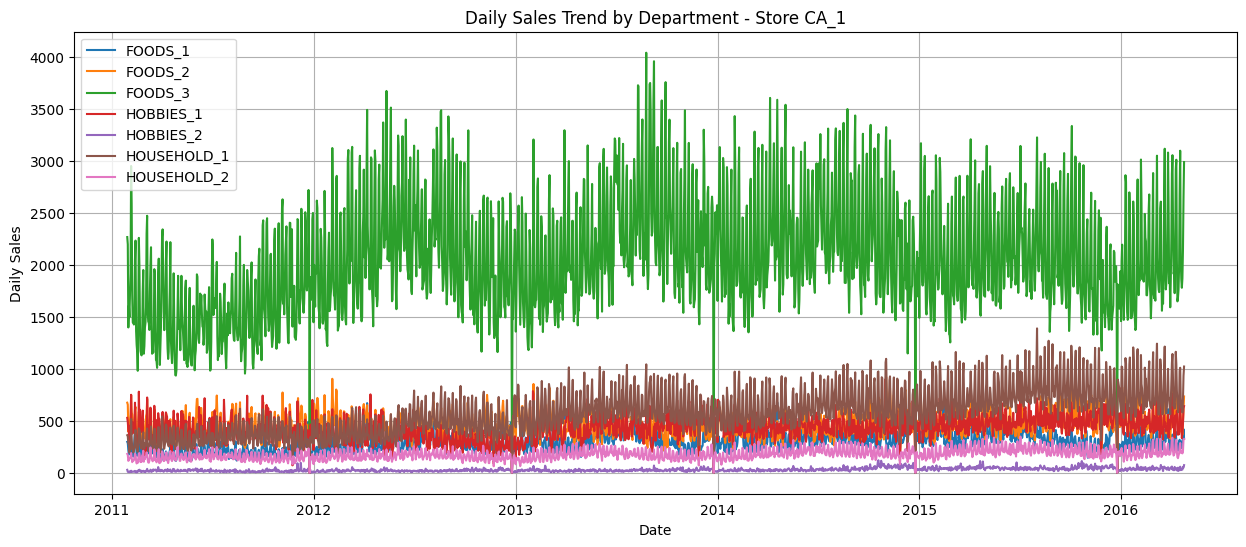

In [18]:
plt.figure(figsize=(15, 6))

for dept in department_daily_df["dept_id"].unique():
    temp_df = department_daily_df[department_daily_df["dept_id"] == dept]
    plt.plot(temp_df["date"], temp_df["sales"], label=dept)

plt.title("Daily Sales Trend by Department - Store CA_1")
plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
department_summary_df = (
    department_daily_df
    .groupby(["dept_id", "cat_id"], as_index=False)
    .agg(
        avg_daily_sales=("sales", "mean"),
        median_daily_sales=("sales", "median"),
        min_daily_sales=("sales", "min"),
        max_daily_sales=("sales", "max"),
        total_sales=("sales", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

department_summary_df

,dept_id,cat_id,avg_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,total_sales
2,FOODS_3,FOODS,2053.233142,1953.0,0,4042,3927835
5,HOUSEHOLD_1,HOUSEHOLD,575.099320,552.0,0,1389,1100165
1,FOODS_2,FOODS,462.699425,447.0,0,923,885144
3,HOBBIES_1,HOBBIES,429.442760,429.0,0,902,821524
0,FOODS_1,FOODS,296.836905,288.0,0,795,567849
6,HOUSEHOLD_2,HOUSEHOLD,178.016205,171.0,0,359,340545
4,HOBBIES_2,HOBBIES,28.831155,25.0,0,120,55154


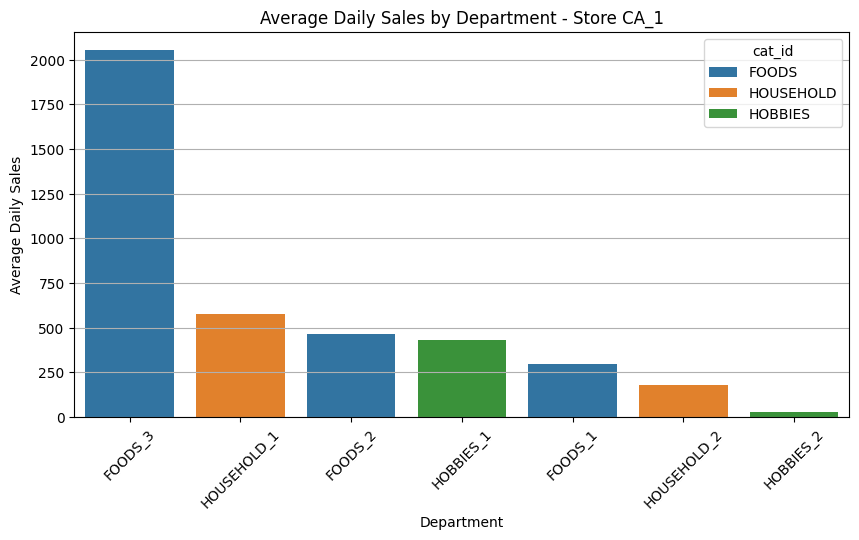

In [20]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=department_summary_df,
    x="dept_id",
    y="avg_daily_sales",
    hue="cat_id"
)

plt.title("Average Daily Sales by Department - Store CA_1")
plt.xlabel("Department")
plt.ylabel("Average Daily Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [21]:
department_daily_df.shape
department_summary_df

,dept_id,cat_id,avg_daily_sales,median_daily_sales,min_daily_sales,max_daily_sales,total_sales
2,FOODS_3,FOODS,2053.233142,1953.0,0,4042,3927835
5,HOUSEHOLD_1,HOUSEHOLD,575.099320,552.0,0,1389,1100165
1,FOODS_2,FOODS,462.699425,447.0,0,923,885144
3,HOBBIES_1,HOBBIES,429.442760,429.0,0,902,821524
0,FOODS_1,FOODS,296.836905,288.0,0,795,567849
6,HOUSEHOLD_2,HOUSEHOLD,178.016205,171.0,0,359,340545
4,HOBBIES_2,HOBBIES,28.831155,25.0,0,120,55154


## 4. Baseline Forecasting

Before training SARIMAX models, we create simple baseline forecasts for each department.

The baseline models help us check whether SARIMAX is actually adding value.

We use:

1. Naive forecast: last observed value
2. 7-day moving average forecast: average of last 7 days

In [22]:
FORECAST_HORIZON = 28

def evaluate_forecast(y_true, y_pred, model_name):
    """
    Evaluate forecast using MAE, RMSE, and MAPE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    y_true_safe = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [23]:
def prepare_department_timeseries(department_daily_df, department_name):
    """
    Prepare daily time series data for one department.
    """
    dept_df = department_daily_df[
        department_daily_df["dept_id"] == department_name
    ].copy()
    
    dept_df = dept_df.sort_values("date")
    
    dept_ts = dept_df[["date", "sales", "snap_CA"]].copy()
    dept_ts = dept_ts.set_index("date")
    dept_ts = dept_ts.asfreq("D")
    
    dept_ts = dept_ts.fillna(0)
    
    return dept_ts

In [24]:
def run_department_baselines(department_daily_df, department_name, forecast_horizon=28):
    """
    Run naive and 7-day moving average baselines for one department.
    """
    dept_ts = prepare_department_timeseries(
        department_daily_df=department_daily_df,
        department_name=department_name
    )
    
    train_data = dept_ts.iloc[:-forecast_horizon].copy()
    test_data = dept_ts.iloc[-forecast_horizon:].copy()
    
    y_train_dept = train_data["sales"]
    y_test_dept = test_data["sales"]
    
    last_observed_value = y_train_dept.iloc[-1]
    naive_forecast = np.repeat(last_observed_value, forecast_horizon)
    
    last_7_day_avg = y_train_dept.iloc[-7:].mean()
    moving_avg_forecast = np.repeat(last_7_day_avg, forecast_horizon)
    
    naive_results = evaluate_forecast(
        y_true=y_test_dept.values,
        y_pred=naive_forecast,
        model_name=f"Naive Forecast - {department_name}"
    )
    
    moving_avg_results = evaluate_forecast(
        y_true=y_test_dept.values,
        y_pred=moving_avg_forecast,
        model_name=f"7-Day Moving Average - {department_name}"
    )
    
    naive_results["dept_id"] = department_name
    moving_avg_results["dept_id"] = department_name
    
    forecast_df = pd.DataFrame({
        "date": y_test_dept.index,
        "dept_id": department_name,
        "actual_sales": y_test_dept.values,
        "naive_forecast": naive_forecast,
        "moving_avg_forecast": moving_avg_forecast
    })
    
    return [naive_results, moving_avg_results], forecast_df

In [25]:
all_departments = department_daily_df["dept_id"].unique().tolist()

all_baseline_metrics = []
all_baseline_forecasts = []

for dept in all_departments:
    print("Running baselines for:", dept)
    
    metrics, forecast_df = run_department_baselines(
        department_daily_df=department_daily_df,
        department_name=dept,
        forecast_horizon=FORECAST_HORIZON
    )
    
    all_baseline_metrics.extend(metrics)
    all_baseline_forecasts.append(forecast_df)
    
    print("Done:", dept)
    print("-" * 50)

department_baseline_results_df = pd.DataFrame(all_baseline_metrics)
department_baseline_results_df.sort_values(["dept_id", "MAPE"])

Running baselines for: FOODS_1
Done: FOODS_1
--------------------------------------------------
Running baselines for: FOODS_2
Done: FOODS_2
--------------------------------------------------
Running baselines for: FOODS_3
Done: FOODS_3
--------------------------------------------------
Running baselines for: HOBBIES_1
Done: HOBBIES_1
--------------------------------------------------
Running baselines for: HOBBIES_2
Done: HOBBIES_2
--------------------------------------------------
Running baselines for: HOUSEHOLD_1
Done: HOUSEHOLD_1
--------------------------------------------------
Running baselines for: HOUSEHOLD_2
Done: HOUSEHOLD_2
--------------------------------------------------


,model,MAE,RMSE,MAPE,dept_id
1,7-Day Moving Average - FOODS_1,120.607143,132.299849,47.643278,FOODS_1
0,Naive Forecast - FOODS_1,125.250000,136.839452,49.373578,FOODS_1
3,7-Day Moving Average - FOODS_2,114.280612,145.144386,19.841647,FOODS_2
2,Naive Forecast - FOODS_2,162.535714,204.273364,26.682364,FOODS_2
5,7-Day Moving Average - FOODS_3,422.183673,485.688676,19.168372,FOODS_3
4,Naive Forecast - FOODS_3,564.214286,613.575353,28.668918,FOODS_3
7,7-Day Moving Average - HOBBIES_1,102.173469,130.167710,18.882729,HOBBIES_1
6,Naive Forecast - HOBBIES_1,162.071429,197.155124,29.027788,HOBBIES_1
8,Naive Forecast - HOBBIES_2,11.250000,15.340190,26.809995,HOBBIES_2
9,7-Day Moving Average - HOBBIES_2,12.117347,13.911711,37.202098,HOBBIES_2


In [26]:
best_department_baseline_df = (
    department_baseline_results_df
    .sort_values(["dept_id", "MAPE"])
    .groupby("dept_id", as_index=False)
    .first()
)

best_department_baseline_df

,dept_id,model,MAE,RMSE,MAPE
0,FOODS_1,7-Day Moving Average - FOODS_1,120.607143,132.299849,47.643278
1,FOODS_2,7-Day Moving Average - FOODS_2,114.280612,145.144386,19.841647
2,FOODS_3,7-Day Moving Average - FOODS_3,422.183673,485.688676,19.168372
3,HOBBIES_1,7-Day Moving Average - HOBBIES_1,102.173469,130.167710,18.882729
4,HOBBIES_2,Naive Forecast - HOBBIES_2,11.250000,15.340190,26.809995
5,HOUSEHOLD_1,7-Day Moving Average - HOUSEHOLD_1,149.316327,193.942580,17.341972
6,HOUSEHOLD_2,Naive Forecast - HOUSEHOLD_2,45.714286,63.037404,18.589247


## 5. SNAP-only SARIMAX Tuning

Now we train and tune SARIMAX models for each department using sales history and SNAP as the external variable.

We test multiple SARIMAX configurations and select the best model per department based on MAPE.

In [27]:
department_sarimax_configs = [
    {
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (1, 1, 0),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 1, 7)
    },
    {
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    },
    {
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 0, 7)
    },
    {
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 7)
    }
]

In [28]:
def run_department_sarimax_pipeline(
    department_daily_df,
    department_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run SARIMAX forecasting pipeline for one department using SNAP as exogenous variable.
    """
    
    dept_ts = prepare_department_timeseries(
        department_daily_df=department_daily_df,
        department_name=department_name
    )
    
    train_data = dept_ts.iloc[:-forecast_horizon].copy()
    test_data = dept_ts.iloc[-forecast_horizon:].copy()
    
    y_train_dept = train_data["sales"]
    y_test_dept = test_data["sales"]
    
    X_train_dept = train_data[["snap_CA"]]
    X_test_dept = test_data[["snap_CA"]]
    
    model = SARIMAX(
        y_train_dept,
        exog=X_train_dept,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_dept
    )
    
    forecast_values = forecast_result.predicted_mean
    
    metrics = evaluate_forecast(
        y_true=y_test_dept.values,
        y_pred=forecast_values.values,
        model_name=f"SARIMAX {order}{seasonal_order} - {department_name}"
    )
    
    metrics["dept_id"] = department_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    metrics["feature_set"] = "snap_only"
    
    forecast_df = pd.DataFrame({
        "date": y_test_dept.index,
        "dept_id": department_name,
        "actual_sales": y_test_dept.values,
        "sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [29]:
def tune_sarimax_for_department(
    department_daily_df,
    department_name,
    configs,
    forecast_horizon=28
):
    """
    Tune SARIMAX models for one department and return all results.
    """
    
    department_results = []
    department_models = {}
    department_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"SARIMAX {order}{seasonal_order} - {department_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_department_sarimax_pipeline(
                department_daily_df=department_daily_df,
                department_name=department_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            department_results.append(metrics)
            department_models[model_label] = model_result
            department_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    department_results_df = pd.DataFrame(department_results)
    
    if department_results_df.empty:
        return department_results_df, department_models, department_forecasts
    
    department_results_df = department_results_df.sort_values("MAPE")
    
    return department_results_df, department_models, department_forecasts

In [30]:
all_department_tuned_results = []
all_department_tuned_models = {}
all_department_tuned_forecasts = {}

for dept in all_departments:
    print("=" * 70)
    print("Tuning department:", dept)
    print("=" * 70)
    
    dept_results_df, dept_models, dept_forecasts = tune_sarimax_for_department(
        department_daily_df=department_daily_df,
        department_name=dept,
        configs=department_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    if dept_results_df.empty:
        print("No successful model for:", dept)
        continue
    
    best_row = dept_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_department_tuned_results.append(best_row)
    all_department_tuned_models[dept] = dept_models[best_model_label]
    all_department_tuned_forecasts[dept] = dept_forecasts[best_model_label]
    
    print("Best model for", dept)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Tuning department: FOODS_1
Training: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1
Done: SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1
MAPE: 25.3 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS_1
Done: SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS_1
MAPE: 49.42 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_1
Done: SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_1
MAPE: 53.31 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_1
Done: SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_1
MAPE: 25.82 %
Converged: True
--------------------------------------------------
Training: SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS_1
Done: SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS_1
MAPE: 36.72 %
Converged: True
--------------------------------------------------
Training: SARIMAX (0, 1, 1)(0, 1, 1, 7) - FOODS_1
Done: SARIMAX (0, 1, 1)(0, 1, 1, 7) - F

In [31]:
all_department_tuned_results_df = pd.DataFrame(all_department_tuned_results)

all_department_tuned_results_df = all_department_tuned_results_df[
    [
        "dept_id",
        "model",
        "feature_set",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_department_tuned_results_df

,dept_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,FOODS_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",91.899638,120.970211,4.252194,25807.687443,True
3,HOUSEHOLD_1,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD_1",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",41.914317,56.808464,5.210369,21393.353263,True
3,FOODS_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",41.335003,49.135903,7.839065,20987.927800,True
3,HOUSEHOLD_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",23.392667,30.338584,9.744222,17361.186462,True
5,HOBBIES_1,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBIES_1",snap_only,"(0, 1, 1)","(0, 1, 1, 7)",77.326587,98.452593,14.429785,21948.952260,True
1,HOBBIES_2,"SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBIES_2",snap_only,"(1, 1, 0)","(1, 1, 1, 7)",10.777788,14.870175,24.033539,14816.534972,True
0,FOODS_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",65.684663,74.100453,25.298692,20309.873949,True


## 6. Calendar-Feature SARIMAX Experiment

The SNAP-only SARIMAX models gave strong results for high-volume departments but struggled with low-volume departments such as HOBBIES_2 and FOODS_1.

To test whether additional external signals improve performance, we add calendar-based features:

- SNAP day indicator
- weekday dummy variables
- month dummy variables
- event indicator

We then tune SARIMAX again and compare it against the SNAP-only models.

In [32]:
department_daily_enriched_df = (
    store_sales_long_df
    .groupby(["date", "dept_id", "cat_id"], as_index=False)
    .agg(
        sales=("sales", "sum"),
        snap_CA=("snap_CA", "max"),
        weekday=("weekday", "first"),
        month=("month", "first"),
        event_name_1=("event_name_1", "first"),
        event_type_1=("event_type_1", "first")
    )
)

department_daily_enriched_df["is_event"] = (
    department_daily_enriched_df["event_name_1"]
    .notna()
    .astype(int)
)

print("Enriched department daily shape:", department_daily_enriched_df.shape)

department_daily_enriched_df.head()

Enriched department daily shape: (13391, 10)


,date,dept_id,cat_id,sales,snap_CA,weekday,month,event_name_1,event_type_1,is_event
0,2011-01-29,FOODS_1,FOODS,297,0,Saturday,1,NaN,NaN,0
1,2011-01-29,FOODS_2,FOODS,674,0,Saturday,1,NaN,NaN,0
2,2011-01-29,FOODS_3,FOODS,2268,0,Saturday,1,NaN,NaN,0
3,2011-01-29,HOBBIES_1,HOBBIES,528,0,Saturday,1,NaN,NaN,0
4,2011-01-29,HOBBIES_2,HOBBIES,28,0,Saturday,1,NaN,NaN,0


In [34]:
def prepare_department_timeseries_with_features(department_daily_enriched_df, department_name):
    """
    Prepare daily department time series with numeric calendar exogenous features.
    """
    dept_df = department_daily_enriched_df[
        department_daily_enriched_df["dept_id"] == department_name
    ].copy()
    
    dept_df = dept_df.sort_values("date")
    
    dept_ts = dept_df[
        ["date", "sales", "snap_CA", "weekday", "month", "is_event"]
    ].copy()
    
    dept_ts = dept_ts.set_index("date")
    dept_ts = dept_ts.asfreq("D")
    
    weekday_dummies = pd.get_dummies(
        dept_ts["weekday"],
        prefix="weekday",
        drop_first=True,
        dtype=int
    )
    
    month_dummies = pd.get_dummies(
        dept_ts["month"].astype(str),
        prefix="month",
        drop_first=True,
        dtype=int
    )
    
    dept_ts = pd.concat(
        [
            dept_ts[["sales", "snap_CA", "is_event"]],
            weekday_dummies,
            month_dummies
        ],
        axis=1
    )
    
    dept_ts = dept_ts.fillna(0)
    dept_ts = dept_ts.apply(pd.to_numeric, errors="coerce").fillna(0)
    dept_ts = dept_ts.astype(float)
    
    return dept_ts

In [35]:
test_dept_ts = prepare_department_timeseries_with_features(
    department_daily_enriched_df=department_daily_enriched_df,
    department_name="FOODS_3"
)

print(test_dept_ts.shape)
print(test_dept_ts.dtypes)

test_dept_ts.head()

(1913, 20)
sales                float64
snap_CA              float64
is_event             float64
weekday_Monday       float64
weekday_Saturday     float64
weekday_Sunday       float64
weekday_Thursday     float64
weekday_Tuesday      float64
weekday_Wednesday    float64
month_10             float64
month_11             float64
month_12             float64
month_2              float64
month_3              float64
month_4              float64
month_5              float64
month_6              float64
month_7              float64
month_8              float64
month_9              float64
dtype: object


,sales,snap_CA,is_event,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,month_10,month_11,month_12,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9
date,,,,,,,,,,,,,,,,,,,,
2011-01-29,2268.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-30,2198.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-31,1398.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-01,1607.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-02-02,1496.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
def run_department_sarimax_with_calendar_features(
    department_daily_enriched_df,
    department_name,
    forecast_horizon=28,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
):
    """
    Run SARIMAX with SNAP + weekday + month + event features for one department.
    """
    
    dept_ts = prepare_department_timeseries_with_features(
        department_daily_enriched_df=department_daily_enriched_df,
        department_name=department_name
    )
    
    train_data = dept_ts.iloc[:-forecast_horizon].copy()
    test_data = dept_ts.iloc[-forecast_horizon:].copy()
    
    y_train_dept = train_data["sales"]
    y_test_dept = test_data["sales"]
    
    X_train_dept = train_data.drop(columns=["sales"])
    X_test_dept = test_data.drop(columns=["sales"])
    
    model = SARIMAX(
        y_train_dept,
        exog=X_train_dept,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit(disp=False, maxiter=100)
    
    forecast_result = result.get_forecast(
        steps=forecast_horizon,
        exog=X_test_dept
    )
    
    forecast_values = forecast_result.predicted_mean
    
    metrics = evaluate_forecast(
        y_true=y_test_dept.values,
        y_pred=forecast_values.values,
        model_name=f"Calendar SARIMAX {order}{seasonal_order} - {department_name}"
    )
    
    metrics["dept_id"] = department_name
    metrics["AIC"] = result.aic
    metrics["order"] = order
    metrics["seasonal_order"] = seasonal_order
    metrics["converged"] = result.mle_retvals.get("converged", None)
    metrics["feature_set"] = "snap_weekday_month_event"
    
    forecast_df = pd.DataFrame({
        "date": y_test_dept.index,
        "dept_id": department_name,
        "actual_sales": y_test_dept.values,
        "calendar_sarimax_forecast": forecast_values.values
    })
    
    return metrics, forecast_df, result

In [37]:
def tune_calendar_sarimax_for_department(
    department_daily_enriched_df,
    department_name,
    configs,
    forecast_horizon=28
):
    """
    Tune calendar-feature SARIMAX models for one department.
    """
    
    department_results = []
    department_models = {}
    department_forecasts = {}
    
    for config in configs:
        order = config["order"]
        seasonal_order = config["seasonal_order"]
        
        model_label = f"Calendar SARIMAX {order}{seasonal_order} - {department_name}"
        
        print("Training:", model_label)
        
        try:
            metrics, forecast_df, model_result = run_department_sarimax_with_calendar_features(
                department_daily_enriched_df=department_daily_enriched_df,
                department_name=department_name,
                forecast_horizon=forecast_horizon,
                order=order,
                seasonal_order=seasonal_order
            )
            
            metrics["model_label"] = model_label
            
            department_results.append(metrics)
            department_models[model_label] = model_result
            department_forecasts[model_label] = forecast_df
            
            print("Done:", model_label)
            print("MAPE:", round(metrics["MAPE"], 2), "%")
            print("Converged:", metrics["converged"])
            print("-" * 50)
            
        except Exception as e:
            print("Failed:", model_label)
            print("Error:", e)
            print("-" * 50)
    
    department_results_df = pd.DataFrame(department_results)
    
    if department_results_df.empty:
        return department_results_df, department_models, department_forecasts
    
    department_results_df = department_results_df.sort_values("MAPE")
    
    return department_results_df, department_models, department_forecasts

In [38]:
all_department_calendar_results = []
all_department_calendar_models = {}
all_department_calendar_forecasts = {}

for dept in all_departments:
    print("=" * 70)
    print("Calendar feature tuning for department:", dept)
    print("=" * 70)
    
    dept_results_df, dept_models, dept_forecasts = tune_calendar_sarimax_for_department(
        department_daily_enriched_df=department_daily_enriched_df,
        department_name=dept,
        configs=department_sarimax_configs,
        forecast_horizon=FORECAST_HORIZON
    )
    
    if dept_results_df.empty:
        print("No successful calendar model for:", dept)
        continue
    
    best_row = dept_results_df.iloc[0]
    best_model_label = best_row["model_label"]
    
    all_department_calendar_results.append(best_row)
    all_department_calendar_models[dept] = dept_models[best_model_label]
    all_department_calendar_forecasts[dept] = dept_forecasts[best_model_label]
    
    print("Best calendar model for", dept)
    print("Model:", best_model_label)
    print("MAPE:", round(best_row["MAPE"], 2), "%")
    print()

Calendar feature tuning for department: FOODS_1
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1
Done: Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1
MAPE: 28.25 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS_1
Done: Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - FOODS_1
MAPE: 53.11 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_1
Done: Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - FOODS_1
MAPE: 56.45 %
Converged: True
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_1
Done: Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_1
MAPE: 21.54 %
Converged: False
--------------------------------------------------
Training: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS_1
Done: Calendar SARIMAX (1, 1, 1)(1, 1, 0, 7) - FOODS_1
MAPE: 36.53 %
Converged: True
--------------------------

In [39]:
all_department_calendar_results_df = pd.DataFrame(all_department_calendar_results)

all_department_calendar_results_df = all_department_calendar_results_df[
    [
        "dept_id",
        "model",
        "feature_set",
        "order",
        "seasonal_order",
        "MAE",
        "RMSE",
        "MAPE",
        "AIC",
        "converged"
    ]
].sort_values("MAPE")

all_department_calendar_results_df

,dept_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,FOODS_3,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",119.265809,140.925470,6.017629,25842.739622,True
2,HOUSEHOLD_1,"Calendar SARIMAX (0, 1, 1)(1, 1, 1, 7) - HOUSE...",snap_weekday_month_event,"(0, 1, 1)","(1, 1, 1, 7)",48.526235,66.667616,6.074381,21475.601879,False
3,FOODS_2,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",44.868260,54.607198,8.230419,20956.054189,True
0,HOUSEHOLD_2,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - HOUSE...",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",29.699369,38.771470,11.941372,17475.526896,False
5,HOBBIES_1,"Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBI...",snap_weekday_month_event,"(0, 1, 1)","(0, 1, 1, 7)",79.181408,90.456270,16.304577,21984.796391,False
3,FOODS_1,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_1",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",54.892290,65.501971,21.542734,20326.565573,False
1,HOBBIES_2,"Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBI...",snap_weekday_month_event,"(1, 1, 0)","(1, 1, 1, 7)",10.461107,14.011590,24.342466,14830.993598,False


## 7. Feature Experiment Comparison

We compare two department-level SARIMAX setups:

1. SNAP-only SARIMAX
2. Calendar-feature SARIMAX using SNAP, weekday, month, and event indicators

Although calendar features improved some individual scores, several calendar-feature models failed to converge.

For final model selection, we prioritize models that:

1. Converged successfully
2. Have the lowest MAPE

In [40]:
snap_only_department_results_df = all_department_tuned_results_df.copy()
calendar_department_results_df = all_department_calendar_results_df.copy()

department_feature_comparison_df = pd.concat(
    [
        snap_only_department_results_df[
            [
                "dept_id",
                "model",
                "feature_set",
                "order",
                "seasonal_order",
                "MAE",
                "RMSE",
                "MAPE",
                "AIC",
                "converged"
            ]
        ],
        calendar_department_results_df[
            [
                "dept_id",
                "model",
                "feature_set",
                "order",
                "seasonal_order",
                "MAE",
                "RMSE",
                "MAPE",
                "AIC",
                "converged"
            ]
        ]
    ],
    ignore_index=True
)

department_feature_comparison_df = department_feature_comparison_df.sort_values(
    ["dept_id", "MAPE"]
)

department_feature_comparison_df

,dept_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
12,FOODS_1,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_1",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",54.892290,65.501971,21.542734,20326.565573,False
6,FOODS_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",65.684663,74.100453,25.298692,20309.873949,True
2,FOODS_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",41.335003,49.135903,7.839065,20987.927800,True
9,FOODS_2,"Calendar SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2",snap_weekday_month_event,"(1, 1, 1)","(0, 1, 1, 7)",44.868260,54.607198,8.230419,20956.054189,True
0,FOODS_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",91.899638,120.970211,4.252194,25807.687443,True
7,FOODS_3,"Calendar SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3",snap_weekday_month_event,"(1, 1, 1)","(1, 1, 1, 7)",119.265809,140.925470,6.017629,25842.739622,True
4,HOBBIES_1,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBIES_1",snap_only,"(0, 1, 1)","(0, 1, 1, 7)",77.326587,98.452593,14.429785,21948.952260,True
11,HOBBIES_1,"Calendar SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBI...",snap_weekday_month_event,"(0, 1, 1)","(0, 1, 1, 7)",79.181408,90.456270,16.304577,21984.796391,False
5,HOBBIES_2,"SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBIES_2",snap_only,"(1, 1, 0)","(1, 1, 1, 7)",10.777788,14.870175,24.033539,14816.534972,True
13,HOBBIES_2,"Calendar SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBI...",snap_weekday_month_event,"(1, 1, 0)","(1, 1, 1, 7)",10.461107,14.011590,24.342466,14830.993598,False


In [41]:
final_department_selected_models_df = (
    department_feature_comparison_df
    .sort_values(["dept_id", "converged", "MAPE"], ascending=[True, False, True])
    .groupby("dept_id", as_index=False)
    .first()
)

final_department_selected_models_df

,dept_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
0,FOODS_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",65.684663,74.100453,25.298692,20309.873949,True
1,FOODS_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",41.335003,49.135903,7.839065,20987.927800,True
2,FOODS_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",91.899638,120.970211,4.252194,25807.687443,True
3,HOBBIES_1,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBIES_1",snap_only,"(0, 1, 1)","(0, 1, 1, 7)",77.326587,98.452593,14.429785,21948.952260,True
4,HOBBIES_2,"SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBIES_2",snap_only,"(1, 1, 0)","(1, 1, 1, 7)",10.777788,14.870175,24.033539,14816.534972,True
5,HOUSEHOLD_1,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD_1",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",41.914317,56.808464,5.210369,21393.353263,True
6,HOUSEHOLD_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",23.392667,30.338584,9.744222,17361.186462,True


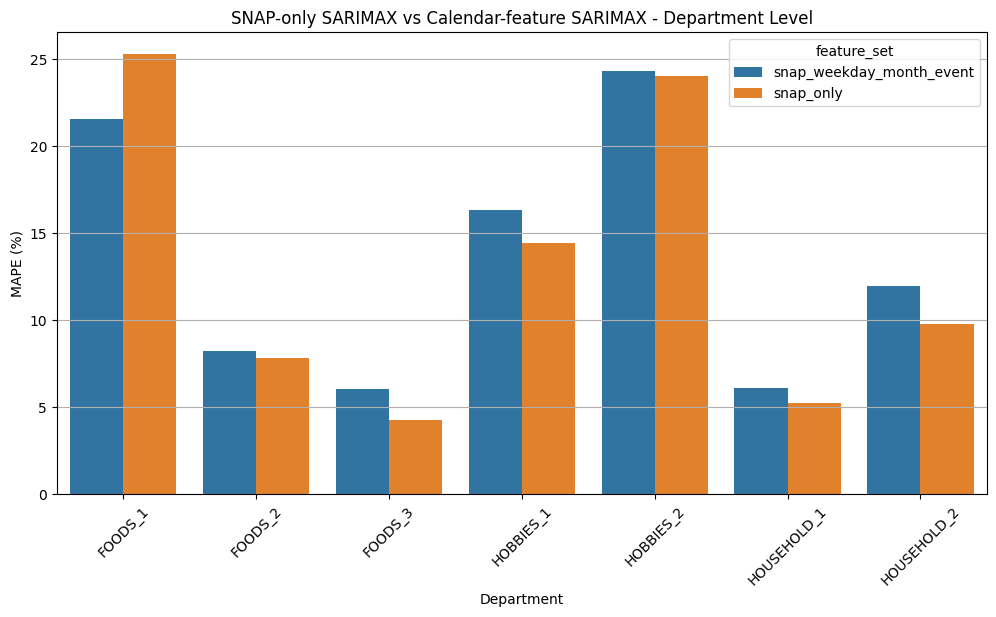

In [42]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=department_feature_comparison_df,
    x="dept_id",
    y="MAPE",
    hue="feature_set"
)

plt.title("SNAP-only SARIMAX vs Calendar-feature SARIMAX - Department Level")
plt.xlabel("Department")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [43]:
department_feature_comparison_path = os.path.join(
    OUTPUTS_DIR,
    "department_feature_comparison_sarimax_CA_1.csv"
)

final_department_selected_models_path = os.path.join(
    OUTPUTS_DIR,
    "final_department_selected_models_CA_1.csv"
)

department_feature_comparison_df.to_csv(
    department_feature_comparison_path,
    index=False
)

final_department_selected_models_df.to_csv(
    final_department_selected_models_path,
    index=False
)

print("Department feature comparison saved to:")
print(department_feature_comparison_path)

print("\nFinal selected department models saved to:")
print(final_department_selected_models_path)

Department feature comparison saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\department_feature_comparison_sarimax_CA_1.csv

Final selected department models saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_selected_models_CA_1.csv


In [44]:
final_department_forecasts_df = pd.concat(
    all_department_tuned_forecasts.values(),
    ignore_index=True
)

final_department_forecasts_df["error"] = (
    final_department_forecasts_df["actual_sales"]
    - final_department_forecasts_df["sarimax_forecast"]
)

final_department_forecasts_df["absolute_error"] = (
    final_department_forecasts_df["error"].abs()
)

final_department_forecasts_df["absolute_percentage_error"] = (
    final_department_forecasts_df["absolute_error"]
    / final_department_forecasts_df["actual_sales"].replace(0, np.nan)
) * 100

print("Final department forecast shape:", final_department_forecasts_df.shape)

final_department_forecasts_df.head()

Final department forecast shape: (196, 7)


,date,dept_id,actual_sales,sarimax_forecast,error,absolute_error,absolute_percentage_error
0,2016-03-28,FOODS_1,233,324.476555,-91.476555,91.476555,39.260324
1,2016-03-29,FOODS_1,185,314.231223,-129.231223,129.231223,69.854715
2,2016-03-30,FOODS_1,215,310.965029,-95.965029,95.965029,44.634897
3,2016-03-31,FOODS_1,354,319.111951,34.888049,34.888049,9.855381
4,2016-04-01,FOODS_1,320,383.073332,-63.073332,63.073332,19.710416


In [45]:
department_forecast_summary_df = (
    final_department_forecasts_df
    .groupby("dept_id", as_index=False)
    .agg(
        forecast_days=("date", "count"),
        avg_actual_sales=("actual_sales", "mean"),
        avg_forecast_sales=("sarimax_forecast", "mean"),
        avg_absolute_error=("absolute_error", "mean"),
        avg_percentage_error=("absolute_percentage_error", "mean")
    )
    .sort_values("avg_percentage_error")
)

department_forecast_summary_df

,dept_id,forecast_days,avg_actual_sales,avg_forecast_sales,avg_absolute_error,avg_percentage_error
2,FOODS_3,28,2201.857143,2169.679077,91.899638,4.252194
5,HOUSEHOLD_1,28,786.000000,758.863575,41.914317,5.210369
1,FOODS_2,28,535.678571,515.036573,41.335003,7.839065
6,HOUSEHOLD_2,28,222.357143,208.057310,23.392667,9.744222
3,HOBBIES_1,28,499.714286,452.456635,77.326587,14.429785
4,HOBBIES_2,28,37.892857,29.468905,10.777788,24.033539
0,FOODS_1,28,286.321429,349.514088,65.684663,25.298692


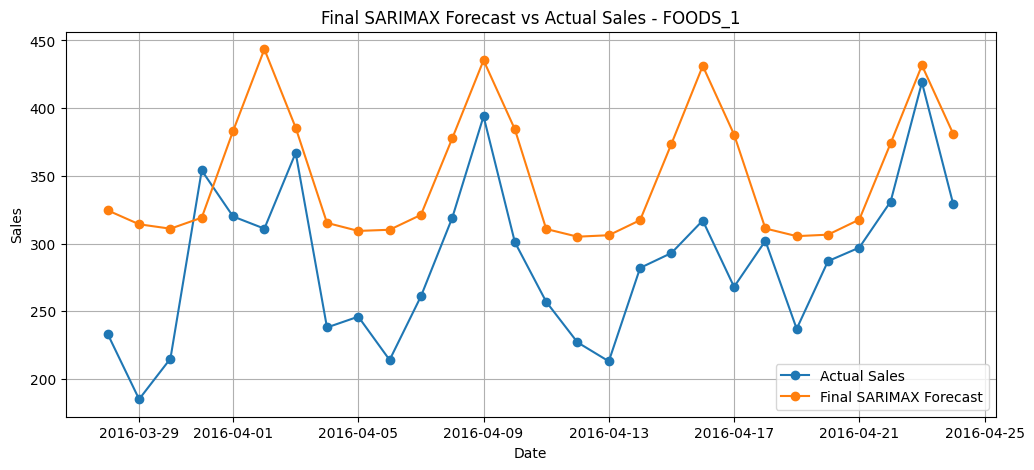

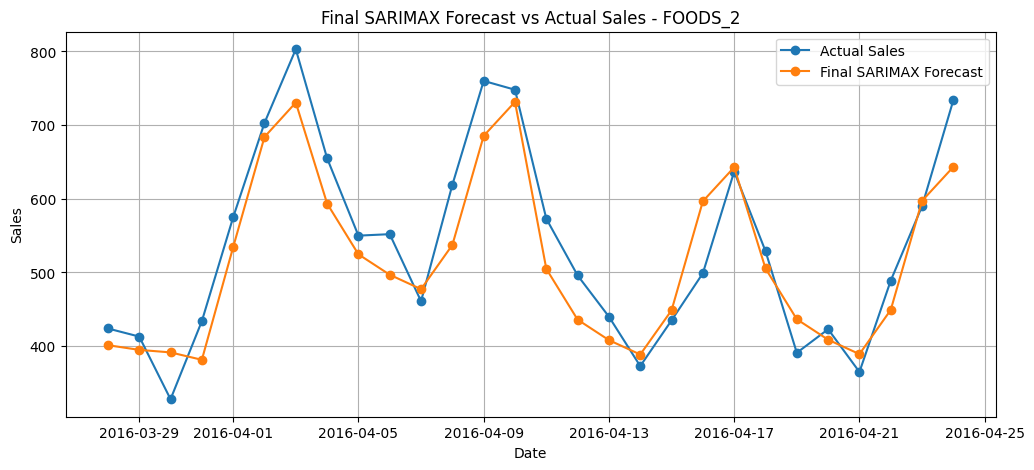

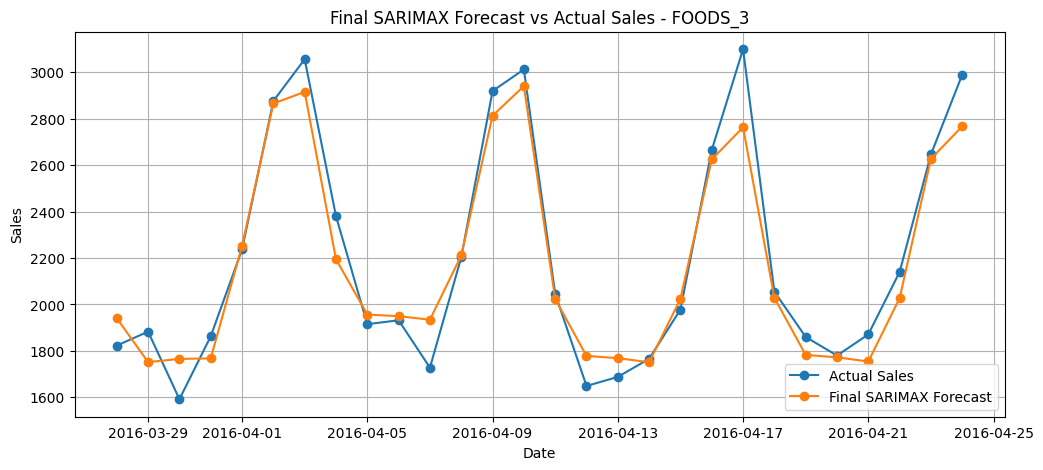

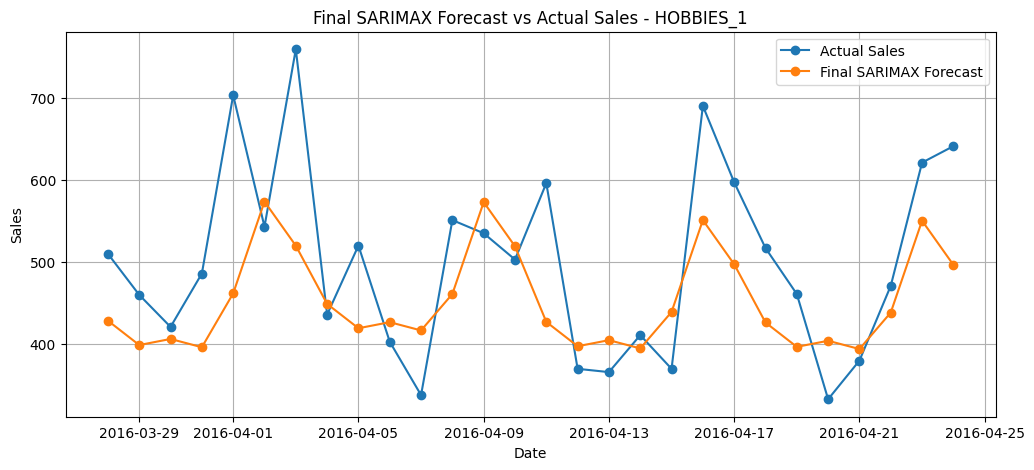

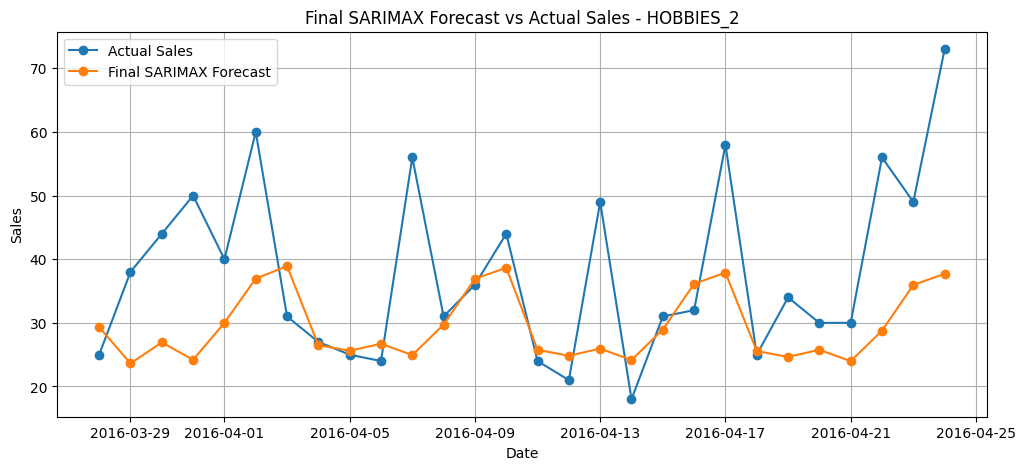

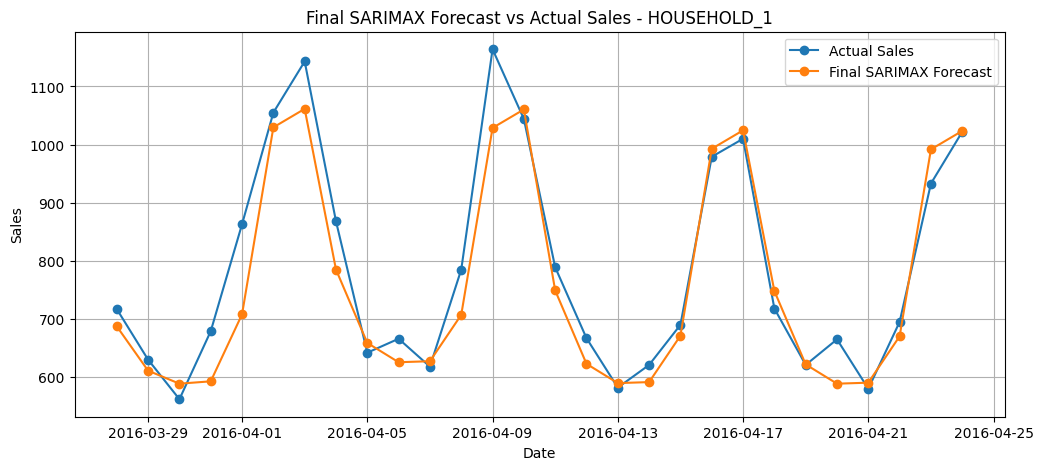

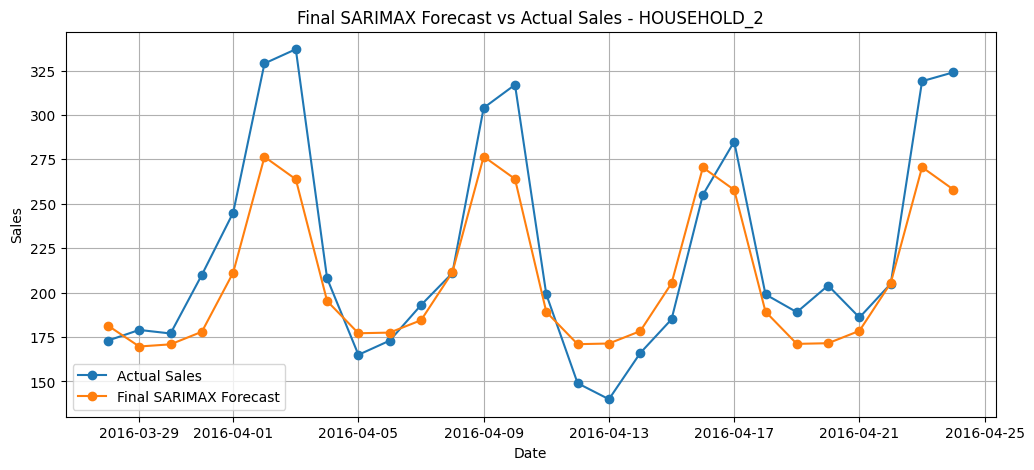

In [46]:
for dept in final_department_forecasts_df["dept_id"].unique():
    temp_df = final_department_forecasts_df[
        final_department_forecasts_df["dept_id"] == dept
    ]
    
    plt.figure(figsize=(12, 5))
    
    plt.plot(
        temp_df["date"],
        temp_df["actual_sales"],
        label="Actual Sales",
        marker="o"
    )
    
    plt.plot(
        temp_df["date"],
        temp_df["sarimax_forecast"],
        label="Final SARIMAX Forecast",
        marker="o"
    )
    
    plt.title(f"Final SARIMAX Forecast vs Actual Sales - {dept}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.show()

In [47]:
final_department_forecasts_path = os.path.join(
    OUTPUTS_DIR,
    "final_department_sarimax_forecasts_CA_1.csv"
)

department_forecast_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_department_forecast_summary_CA_1.csv"
)

final_department_forecasts_df.to_csv(
    final_department_forecasts_path,
    index=False
)

department_forecast_summary_df.to_csv(
    department_forecast_summary_path,
    index=False
)

print("Final department forecasts saved to:")
print(final_department_forecasts_path)

print("\nDepartment forecast summary saved to:")
print(department_forecast_summary_path)

Final department forecasts saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_sarimax_forecasts_CA_1.csv

Department forecast summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_forecast_summary_CA_1.csv


In [48]:
for dept, model_result in all_department_tuned_models.items():
    model_path = os.path.join(
        MODELS_DIR,
        f"best_sarimax_{dept.lower()}_CA_1.pkl"
    )
    
    joblib.dump(model_result, model_path)
    
    print(f"Saved {dept} model to:")
    print(model_path)

Saved FOODS_1 model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_foods_1_CA_1.pkl
Saved FOODS_2 model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_foods_2_CA_1.pkl
Saved FOODS_3 model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_foods_3_CA_1.pkl
Saved HOBBIES_1 model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_hobbies_1_CA_1.pkl
Saved HOBBIES_2 model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_hobbies_2_CA_1.pkl
Saved HOUSEHOLD_1 model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_household_1_CA_1.pkl
Saved HOUSEHOLD_2 model to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\models\best_sarimax_household_2_CA_1.pkl


## 8. Final Conclusion

This notebook built a department-level demand forecasting pipeline for Walmart store CA_1 using the M5 dataset.

The raw item-level sales data was converted from wide format into long format, enriched with calendar information, and aggregated into 7 department-level time series.

We trained baseline models, tuned SNAP-only SARIMAX models, and tested calendar-feature SARIMAX models using weekday, month, and event indicators.

The final selected models were SNAP-only SARIMAX models because they achieved better stability and convergence compared to the calendar-feature models.

### Final Department-Level Insights

- FOODS_3 is the highest-volume department and achieved the strongest forecast performance.
- HOUSEHOLD_1 and FOODS_2 also showed strong forecast accuracy.
- HOBBIES_2 and FOODS_1 had higher MAPE because of lower volume and more irregular demand behavior.
- Calendar features did not consistently improve performance and created convergence issues for several departments.
- SNAP-only SARIMAX was selected as the final department-level modeling approach.

### Business Takeaways

1. High-volume departments such as FOODS_3 should be prioritized for inventory planning.
2. Department-level forecasting gives more detailed demand visibility than category-level forecasting.
3. Low-volume departments require additional signals such as price, promotions, or item-level demand behavior.
4. A single forecasting strategy may not work equally well across all departments.
5. Department-level outputs can be used for stock planning, replenishment decisions, and sales planning dashboards.

In [49]:
final_department_notebook_summary = {
    "store": SELECTED_STORE,
    "forecast_level": "department",
    "forecast_horizon_days": FORECAST_HORIZON,
    "number_of_departments": len(all_departments),
    "final_feature_set": "snap_only",
    "best_department": department_forecast_summary_df.iloc[0]["dept_id"],
    "best_department_mape": department_forecast_summary_df.iloc[0]["avg_percentage_error"],
    "weakest_department": department_forecast_summary_df.iloc[-1]["dept_id"],
    "weakest_department_mape": department_forecast_summary_df.iloc[-1]["avg_percentage_error"],
    "average_mape_across_departments": department_forecast_summary_df["avg_percentage_error"].mean()
}

final_department_notebook_summary_df = pd.DataFrame([final_department_notebook_summary])

final_department_summary_path = os.path.join(
    OUTPUTS_DIR,
    "final_department_forecasting_summary_CA_1.csv"
)

final_department_notebook_summary_df.to_csv(
    final_department_summary_path,
    index=False
)

print("Final department forecasting summary saved to:")
print(final_department_summary_path)

final_department_notebook_summary_df

Final department forecasting summary saved to:
c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_forecasting_summary_CA_1.csv


,store,forecast_level,forecast_horizon_days,number_of_departments,final_feature_set,best_department,best_department_mape,weakest_department,weakest_department_mape,average_mape_across_departments
0,CA_1,department,28,7,snap_only,FOODS_3,4.252194,FOODS_1,25.298692,12.972552


In [50]:
final_department_selected_models_df.sort_values("MAPE")

,dept_id,model,feature_set,order,seasonal_order,MAE,RMSE,MAPE,AIC,converged
2,FOODS_3,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_3",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",91.899638,120.970211,4.252194,25807.687443,True
5,HOUSEHOLD_1,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD_1",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",41.914317,56.808464,5.210369,21393.353263,True
1,FOODS_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - FOODS_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",41.335003,49.135903,7.839065,20987.927800,True
6,HOUSEHOLD_2,"SARIMAX (1, 1, 1)(0, 1, 1, 7) - HOUSEHOLD_2",snap_only,"(1, 1, 1)","(0, 1, 1, 7)",23.392667,30.338584,9.744222,17361.186462,True
3,HOBBIES_1,"SARIMAX (0, 1, 1)(0, 1, 1, 7) - HOBBIES_1",snap_only,"(0, 1, 1)","(0, 1, 1, 7)",77.326587,98.452593,14.429785,21948.952260,True
4,HOBBIES_2,"SARIMAX (1, 1, 0)(1, 1, 1, 7) - HOBBIES_2",snap_only,"(1, 1, 0)","(1, 1, 1, 7)",10.777788,14.870175,24.033539,14816.534972,True
0,FOODS_1,"SARIMAX (1, 1, 1)(1, 1, 1, 7) - FOODS_1",snap_only,"(1, 1, 1)","(1, 1, 1, 7)",65.684663,74.100453,25.298692,20309.873949,True


In [51]:
print("Department notebook completed successfully.")
print()
print("Saved files:")
print("1.", department_processed_path)
print("2.", department_feature_comparison_path)
print("3.", final_department_selected_models_path)
print("4.", final_department_forecasts_path)
print("5.", department_forecast_summary_path)
print("6.", final_department_summary_path)

Department notebook completed successfully.

Saved files:
1. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\data\processed\department_daily_sales_CA_1.csv
2. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\department_feature_comparison_sarimax_CA_1.csv
3. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_selected_models_CA_1.csv
4. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_sarimax_forecasts_CA_1.csv
5. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_forecast_summary_CA_1.csv
6. c:\Users\KIIT\Desktop\PROJECTS\m5_retail_demand_forecasting\outputs\final_department_forecasting_summary_CA_1.csv
